In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import datetime

# Configuration
RESULTS_DIR = Path("../results")


In [2]:
%matplotlib widget

In [6]:
# Enter the filename to load (without path, or with full path)
filename = "v_meas_20251213-173821.json"  # Change this to your filename

# Construct full path
if Path(filename).is_absolute():
    filepath = Path(filename)
else:
    filepath = RESULTS_DIR / filename

print(f"Loading data from: {filepath}")


Loading data from: ../results/v_meas_20251213-173821.json


In [7]:
# Load the JSON data
with open(filepath, 'r') as f:
    data = json.load(f)

# Display metadata
print(f"Measurement timestamp: {data['timestamp']}")
print(f"Measurement time: {data['measurement_time']}")
if 'sec_utc' in data:
    dt = datetime.datetime.fromtimestamp(data['sec_utc'])
    print(f"UTC time: {dt.strftime('%Y-%m-%d %H:%M:%S UTC')}")
print(f"Sample rate: {data['sample_rate_hz']} Hz")
print(f"Duration: {data['measurement_duration_s']} s")
print(f"Buffer size: {data['buffer_size']} samples")
print(f"Channel range: ±{data['channel_range_v']} V")
print(f"Number of voltage samples: {len(data['voltage_data_v'])}")
print(f"Number of time samples: {len(data['time_s'])}")


Measurement timestamp: 20251213-173821
Measurement time: 2025-12-13 17:38:29
UTC time: 2025-12-13 17:38:29 UTC
Sample rate: 1000.0 Hz
Duration: 8.0 s
Buffer size: 8000 samples
Channel range: ±0.5 V
Number of voltage samples: 8000
Number of time samples: 8000


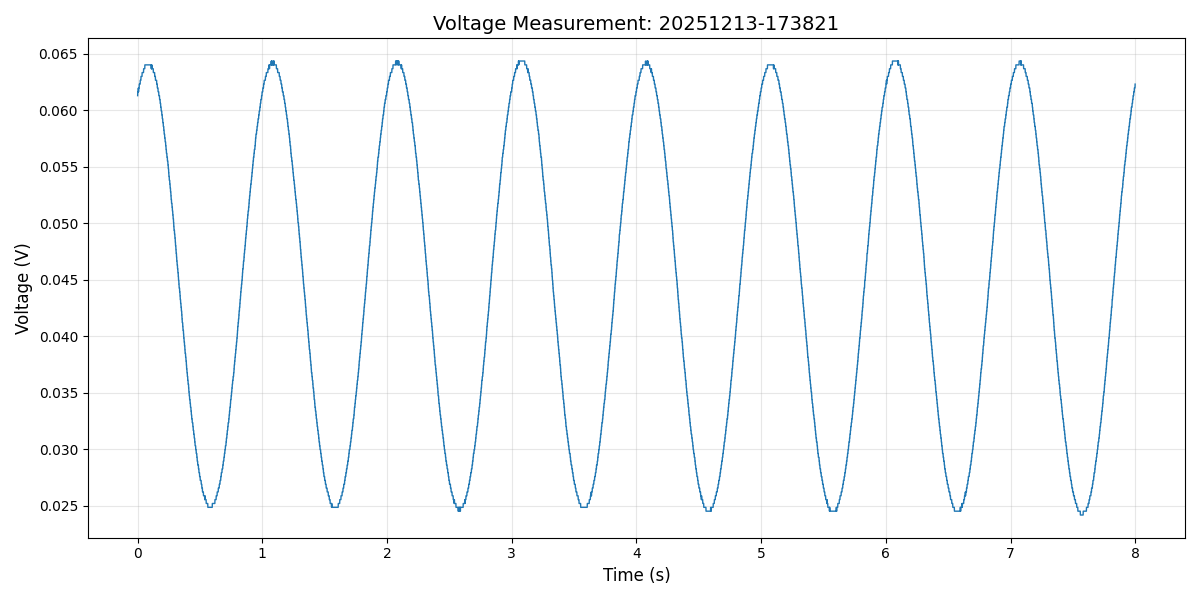


Voltage Statistics:
  Min: 0.024185 V
  Max: 0.064352 V
  Mean: 0.044411 V
  Std: 0.014038 V


In [8]:
# Extract data arrays
time_s = np.array(data['time_s'])  # Time in seconds
voltage_v = np.array(data['voltage_data_v'])  # Voltage in Volts

# Plot voltage vs time
plt.figure(figsize=(12, 6))
plt.plot(time_s, voltage_v, linewidth=1)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Voltage (V)', fontsize=12)
plt.title(f'Voltage Measurement: {data["timestamp"]}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"\nVoltage Statistics:")
print(f"  Min: {np.min(voltage_v):.6f} V")
print(f"  Max: {np.max(voltage_v):.6f} V")
print(f"  Mean: {np.mean(voltage_v):.6f} V")
print(f"  Std: {np.std(voltage_v):.6f} V")
